# World-model loss (M3)

Run the full world model on a short replay batch and plot the four loss
terms separately: reconstruction, reward, continue, and KL (dyn/rep).

Uses `data/m3_replay.pt` if present, otherwise collects a few random episodes.


In [ ]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import yaml

from models.preprocess import nchw_float_to_nhwc_uint8, nhwc_uint8_to_nchw_float
from models.world_model import WorldModel
from training.device import configure_runtime, describe_device, get_device, warn_if_not_cuda
from training.losses import world_model_loss
from training.replay_buffer import ReplayBuffer, collect_random_episodes

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

%matplotlib inline

CONFIG = Path("configs/m3_world_model.yaml")
with CONFIG.open() as f:
    cfg = yaml.safe_load(f)

device = get_device()
configure_runtime(device)
print(f"device: {describe_device(device)}")
warn_if_not_cuda(device)


device: mps


## Load or collect replay


In [2]:
replay_path = Path(cfg["collect"]["out_path"])
buffer = ReplayBuffer(seed=int(cfg["seed"]))
if replay_path.exists():
    buffer.load_state_dict(torch.load(replay_path, weights_only=False))
    print(f"loaded {replay_path}: episodes={len(buffer)} steps={buffer.num_steps}")
else:
    print("no replay dump — collecting 6 short random episodes...")
    buffer = collect_random_episodes(
        env_id=str(cfg["env"]["id"]),
        num_episodes=6,
        max_episode_steps=120,
        action_dim=int(cfg["env"]["action_dim"]),
        seed=int(cfg["seed"]),
    )
    print(f"collected episodes={len(buffer)} steps={buffer.num_steps}")


loaded data/m3_replay.pt: episodes=40 steps=6826


## Build model + one forward/backward


In [3]:
enc, rssm, dec, heads, train = (
    cfg["encoder"],
    cfg["rssm"],
    cfg.get("decoder", {}),
    cfg.get("heads", {}),
    cfg["train"],
)
model = WorldModel.from_config_dims(
    embed_dim=int(enc["embed_dim"]),
    encoder_channels=tuple(int(c) for c in enc["channels"]),
    action_dim=int(cfg["env"]["action_dim"]),
    deter_dim=int(rssm["deter_dim"]),
    stoch=int(rssm["stoch"]),
    classes=int(rssm["classes"]),
    hidden=int(rssm["hidden"]),
    unimix=float(rssm.get("unimix", 0.01)),
    act=str(rssm.get("act", "silu")),
    initial=str(rssm.get("initial", "learned")),
    rec_depth=int(rssm.get("rec_depth", 1)),
    decoder_channels=tuple(int(c) for c in dec.get("channels", [256, 128, 64, 32])),
    head_hidden=int(heads.get("hidden", 512)),
    head_layers=int(heads.get("layers", 2)),
    spatial=int(enc.get("spatial", 4)),
).to(device)

batch = buffer.sample(batch_size=4, seq_len=24)
obs = batch["obs"].to(device)
out = model(obs, batch["actions"].to(device))
b, t = obs.shape[:2]
obs_f = nhwc_uint8_to_nchw_float(obs.reshape(b * t, *obs.shape[2:])).view(b, t, 3, 64, 64)
loss = world_model_loss(
    obs=obs_f,
    recon=out.recon,
    reward=batch["rewards"].to(device),
    reward_pred=out.reward_pred,
    cont=batch["cont"].to(device),
    cont_logit=out.cont_logit,
    post_logits=out.rssm.posterior_logits,
    prior_logits=out.rssm.prior_logits,
    unimix=model.rssm.unimix,
    dyn_scale=float(train["dyn_scale"]),
    rep_scale=float(train["rep_scale"]),
    free_nats=float(train["free_nats"]),
)
loss.total.backward()

terms = {
    "recon": float(loss.recon.detach()),
    "reward": float(loss.reward.detach()),
    "continue": float(loss.continue_loss.detach()),
    "kl": float(loss.kl.detach()),
    "kl_dyn": float(loss.kl_dyn.detach()),
    "kl_rep": float(loss.kl_rep.detach()),
}
print("loss terms:", terms)


loss terms: {'recon': 0.6102210879325867, 'reward': 0.0705469474196434, 'continue': 0.5537309050559998, 'kl': 0.6000000238418579, 'kl_dyn': 1.0, 'kl_rep': 1.0}


## Loss bars + recon grid


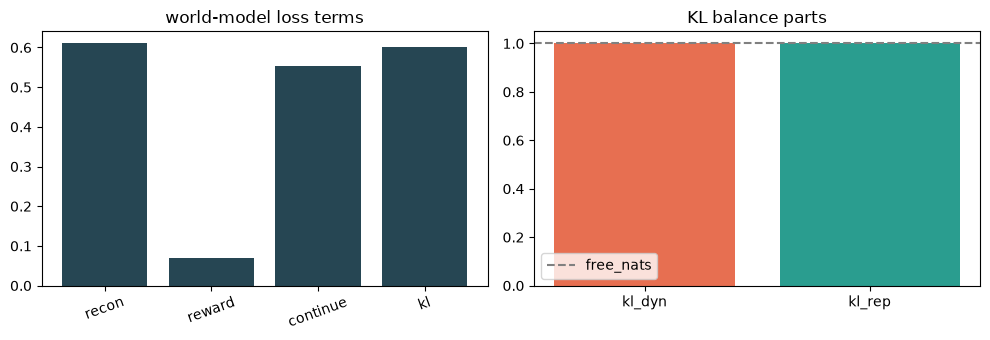

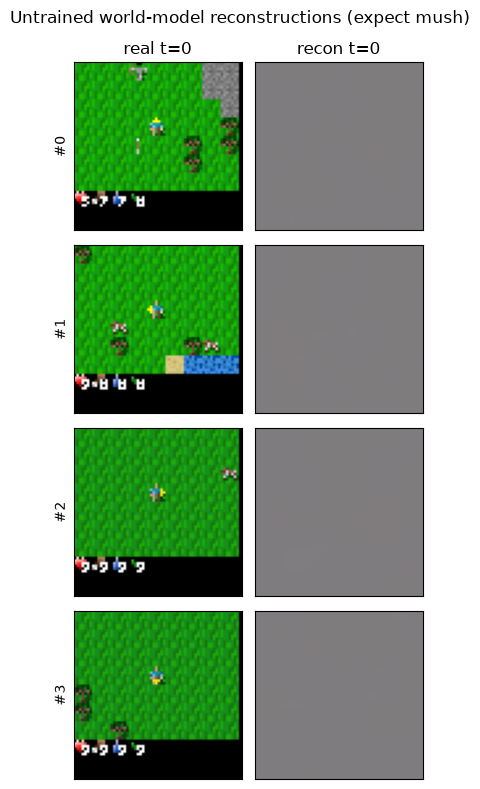

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
main_keys = ["recon", "reward", "continue", "kl"]
axes[0].bar(main_keys, [terms[k] for k in main_keys], color="#264653")
axes[0].set_title("world-model loss terms")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(["kl_dyn", "kl_rep"], [terms["kl_dyn"], terms["kl_rep"]], color=["#e76f51", "#2a9d8f"])
axes[1].axhline(float(train["free_nats"]), color="gray", linestyle="--", label="free_nats")
axes[1].set_title("KL balance parts")
axes[1].legend()
fig.tight_layout()
plt.show()

real = obs[:, 0].detach().cpu()
pred = nchw_float_to_nhwc_uint8(out.recon[:, 0].detach().cpu())
n = real.shape[0]
fig, axes = plt.subplots(n, 2, figsize=(4, 2 * n))
if n == 1:
    axes = [axes]
for i in range(n):
    axes[i][0].imshow(real[i].numpy())
    axes[i][1].imshow(pred[i].numpy())
    axes[i][0].set_ylabel(f"#{i}")
    for ax in axes[i]:
        ax.set_xticks([])
        ax.set_yticks([])
axes[0][0].set_title("real t=0")
axes[0][1].set_title("recon t=0")
fig.suptitle("Untrained world-model reconstructions (expect mush)")
fig.tight_layout()
plt.show()


## Mini train curve (optional)

A few dozen steps so you can watch terms move. Full training stays in
`scripts/train_world_model.py`.


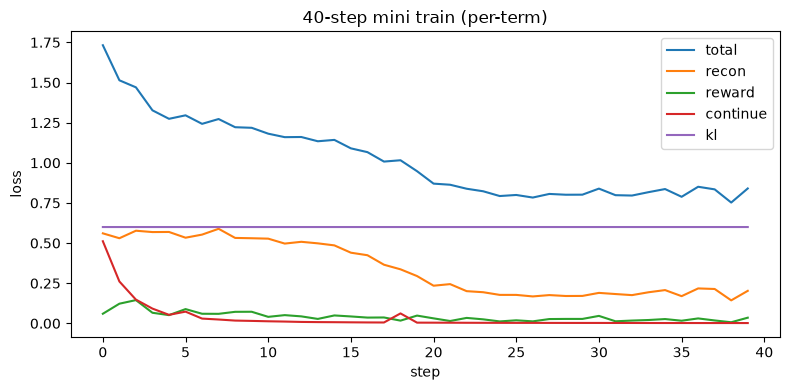

{'total': (1.7321840524673462, 0.8401281237602234), 'recon': (0.5606793165206909, 0.20264188945293427), 'reward': (0.05998765677213669, 0.035445436835289), 'continue': (0.5115169882774353, 0.002040792489424348), 'kl': (0.6000000238418579, 0.6000000238418579)}


In [5]:
STEPS = 40
optim = torch.optim.Adam(model.parameters(), lr=float(train["lr"]))
curves = {k: [] for k in ["total", "recon", "reward", "continue", "kl"]}

model.train()
for step in range(1, STEPS + 1):
    batch = buffer.sample(4, 24)
    obs = batch["obs"].to(device)
    out = model(obs, batch["actions"].to(device))
    b, t = obs.shape[:2]
    obs_f = nhwc_uint8_to_nchw_float(obs.reshape(b * t, *obs.shape[2:])).view(b, t, 3, 64, 64)
    loss = world_model_loss(
        obs=obs_f,
        recon=out.recon,
        reward=batch["rewards"].to(device),
        reward_pred=out.reward_pred,
        cont=batch["cont"].to(device),
        cont_logit=out.cont_logit,
        post_logits=out.rssm.posterior_logits,
        prior_logits=out.rssm.prior_logits,
        unimix=model.rssm.unimix,
        dyn_scale=float(train["dyn_scale"]),
        rep_scale=float(train["rep_scale"]),
        free_nats=float(train["free_nats"]),
    )
    optim.zero_grad(set_to_none=True)
    loss.total.backward()
    optim.step()
    curves["total"].append(float(loss.total.detach()))
    curves["recon"].append(float(loss.recon.detach()))
    curves["reward"].append(float(loss.reward.detach()))
    curves["continue"].append(float(loss.continue_loss.detach()))
    curves["kl"].append(float(loss.kl.detach()))

fig, ax = plt.subplots(figsize=(8, 4))
for k, ys in curves.items():
    ax.plot(ys, label=k)
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title(f"{STEPS}-step mini train (per-term)")
ax.legend()
fig.tight_layout()
plt.show()
print({k: (ys[0], ys[-1]) for k, ys in curves.items()})
